# 911 Calls Project

For this project we will be analyzing some 911 call data from [Kaggle](https://www.kaggle.com/mchirico/montcoalert). The data contains the following fields:

* lat : String variable, Latitude
* lng: String variable, Longitude
* desc: String variable, Description of the Emergency Call
* zip: String variable, Zipcode
* title: String variable, Title
* timeStamp: String variable, YYYY-MM-DD HH:MM:SS
* twp: String variable, Township
* addr: String variable, Address
* e: String variable, Dummy variable (always 1)

Just go along with this notebook and try to complete the instructions or answer the questions in bold using your Python and Data Science skills!

## Data and Setup

> Imports (no numpy needed): 

In [1]:
# dissable python cachin (no need)
import sys
sys.dont_write_bytecode = True

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

-  Read in the csv file as a dataframe called df
-  Check the info() of the df
-  Check the head of df

In [2]:
df = pd.read_csv("data/am1CallData.csv")
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  str    
 3   zip        86637 non-null  float64
 4   title      99492 non-null  str    
 5   timeStamp  99492 non-null  str    
 6   twp        99449 non-null  str    
 7   addr       98973 non-null  str    
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 6.8 MB


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


## Basic Questions

> What are the top 5 zipcodes for 911 calls?

In [3]:
df["zip"].value_counts().head(n=5)

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

> What are the top 5 townships (twp) for 911 calls?

In [4]:
df["twp"].value_counts().head(5)

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

> Take a look at the 'title' column, how many unique title codes are there? 

In [5]:
df["title"].nunique()

110

> Creating new features

*In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Use .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.*

**For example, if the title column value is EMS: BACK PAINS/INJURY , the Reason column value would be EMS. 
Please try to answer the following questions:**

**What is the most common Reason for a 911 call based off of this new column? and please visualize them by seaborn**
- What is the data type of the objects in the timeStamp column? 
- If it is not in datetime object use pd.to_datetime to convert the column to DateTime objects.
- Make new feature include Hour, Month, and Day of Week=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'].
- Now use seaborn to create a countplot of the Day of Week column with the hue based of the Reason column.
- do the same for Month.

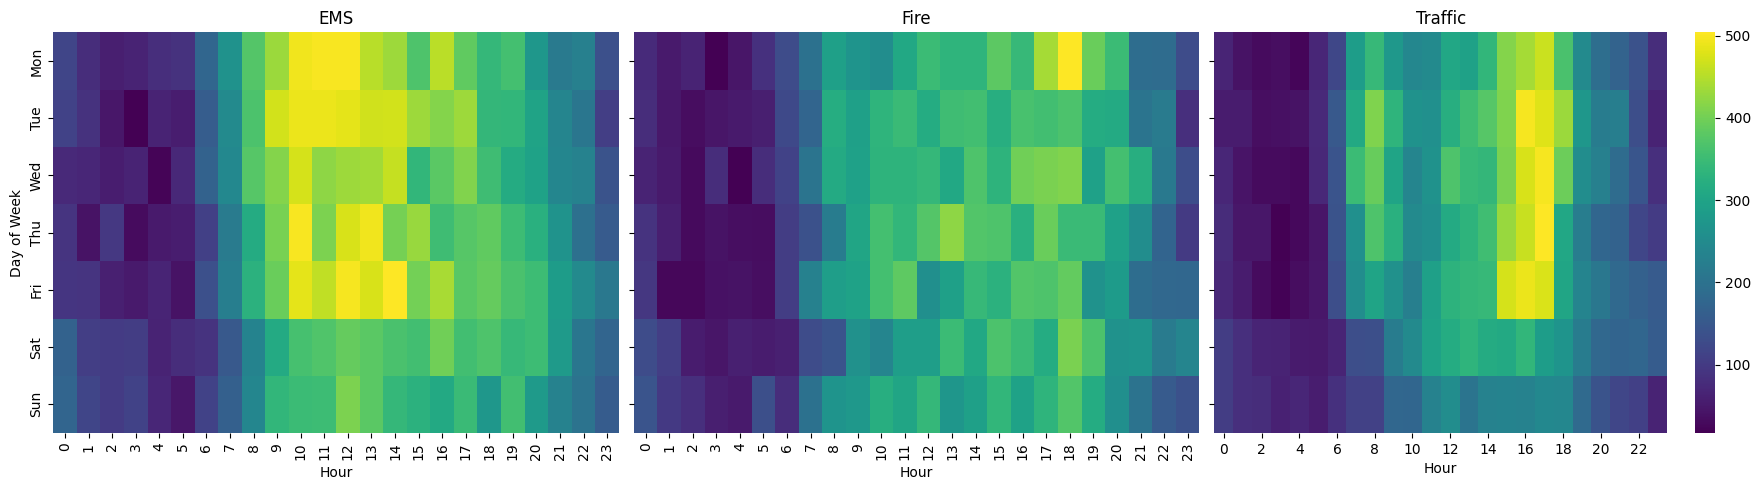

In [6]:
# ensure datetime
df["timeStamp"] = pd.to_datetime(df["timeStamp"])

# recreate required columns
df["Reason"] = df["title"].str.split(":").str[0]
df["Hour"] = df["timeStamp"].dt.hour
df["Month"] = df["timeStamp"].dt.month
df["Day of Week"] = df["timeStamp"].dt.day_name().str[:3]

order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
rsn = df["Reason"].unique()

fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, r in enumerate(rsn):
    tmp = (
        df[df["Reason"] == r]
        .groupby(["Day of Week", "Hour"])
        .size()
        .unstack(fill_value=0)
        .reindex(order)
    )

    sns.heatmap(tmp, cmap="viridis", ax=ax[i], cbar=i == 2)
    ax[i].set_title(r)
    ax[i].set_xlabel("Hour")

    if i == 0:
        ax[i].set_ylabel("Day of Week")
    else:
        ax[i].set_ylabel("")

plt.tight_layout()
plt.show()

> Did you notice something strange about the Plot 

- 1: Seaborn plots categories in alphabetical order by default, so the days likely appear as: Fri, Mon, Sat, Sun, Thu, Tue, Wed
- 2: Data from some months are missing


> Create a simple plot off of the dataframe indicating the count of calls per month

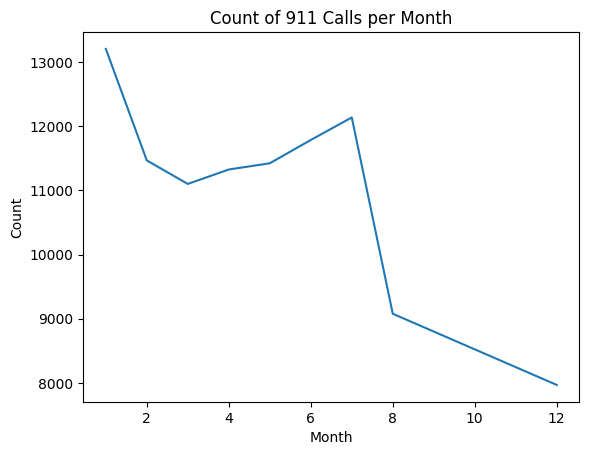

In [7]:
# group by Month and count calls
byMonth = df.groupby("Month").count()

# simple line plot of calls per month
byMonth["Reason"].plot()
plt.title("Count of 911 Calls per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

> Now see if you can use seaborn's lmplot() to create a linear fit on the number of calls per month. Keep in mind you may need to reset the index to a column

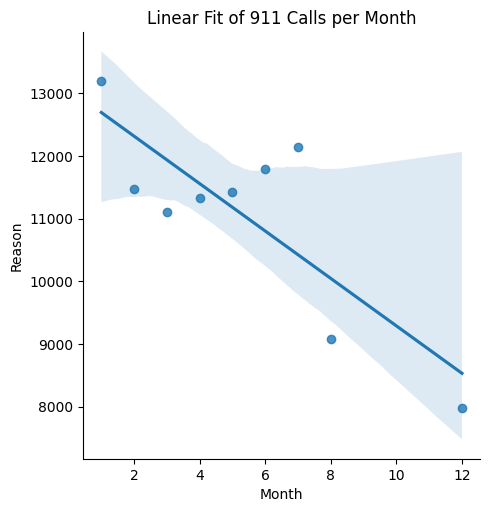

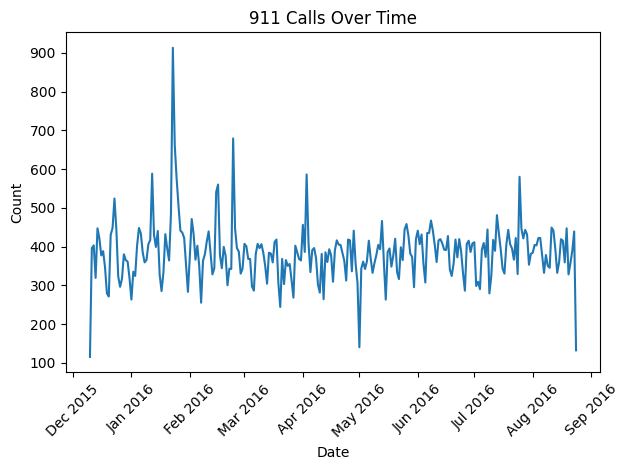

In [8]:
# ───| Asked solution
# group by Month and count calls
byMonth = df.groupby("Month").count()

# reset index to turn Month into a column
byMonth = byMonth.reset_index()

# lmplot with linear fit
sns.lmplot(x="Month", y="Reason", data=byMonth)

plt.title("Linear Fit of 911 Calls per Month")
plt.show()

# ───| Better solution
import matplotlib.dates as mdates
# keep as datetime (do NOT convert to .dt.date)
byDate = df.groupby(df["timeStamp"].dt.date).count()["Reason"]

# plot
fig, ax = plt.subplots()
byDate.plot(ax=ax)

# format ticks (monthly spacing)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.title("911 Calls Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

lmplot() fits because:

- Month is numeric (1–12).
- The aggregated call count per month is numeric.
- Linear regression can therefore compute a best-fit line.

However, it is not ideal.

Why it is weak here

- Month is cyclical (December → January resets).
- We have only have ~12 data points.

It assumes a linear trend across months.
Seasonality is ignored.

> Create a new column called 'Date' that contains the date from the timeStamp column. You'll need to use apply along with the .date() method

In [9]:
df["Date"] = df["timeStamp"].apply(lambda t: t.date())

> Now groupby this Date column with the count() aggregate and create a plot of counts of 911 calls

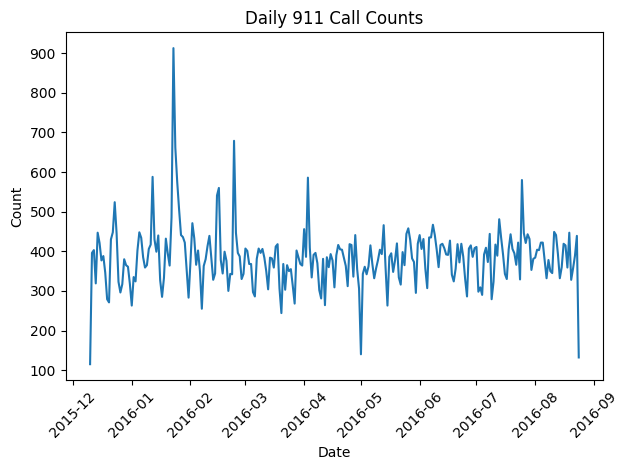

In [10]:
# group by Date and count calls
byDate = df.groupby("Date").count()["Reason"]

# plot counts per day
byDate.plot()
plt.title("Daily 911 Call Counts")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> Now recreate this plot but create 3 separate plots with each plot representing a Reason for the 911 call

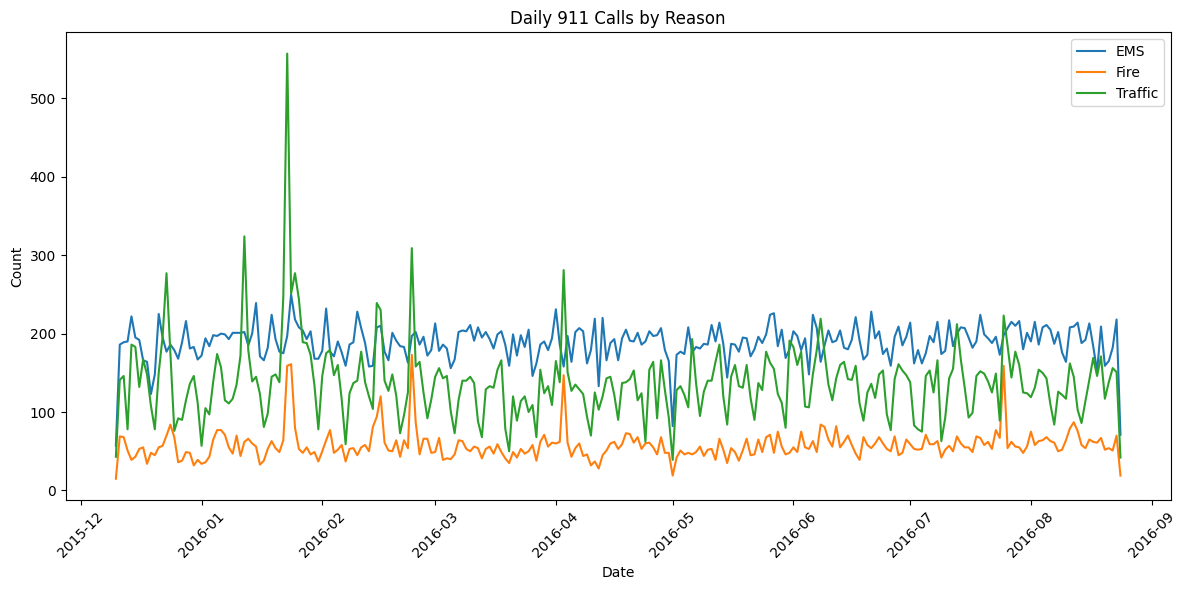

In [11]:
rsn = df["Reason"].unique()

plt.figure(figsize=(12, 6))

for r in rsn:
    byDate = df[df["Reason"] == r].groupby("Date").count()["Reason"]
    byDate.plot(label=r)

plt.title("Daily 911 Calls by Reason")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> Clustermap using DataFrame

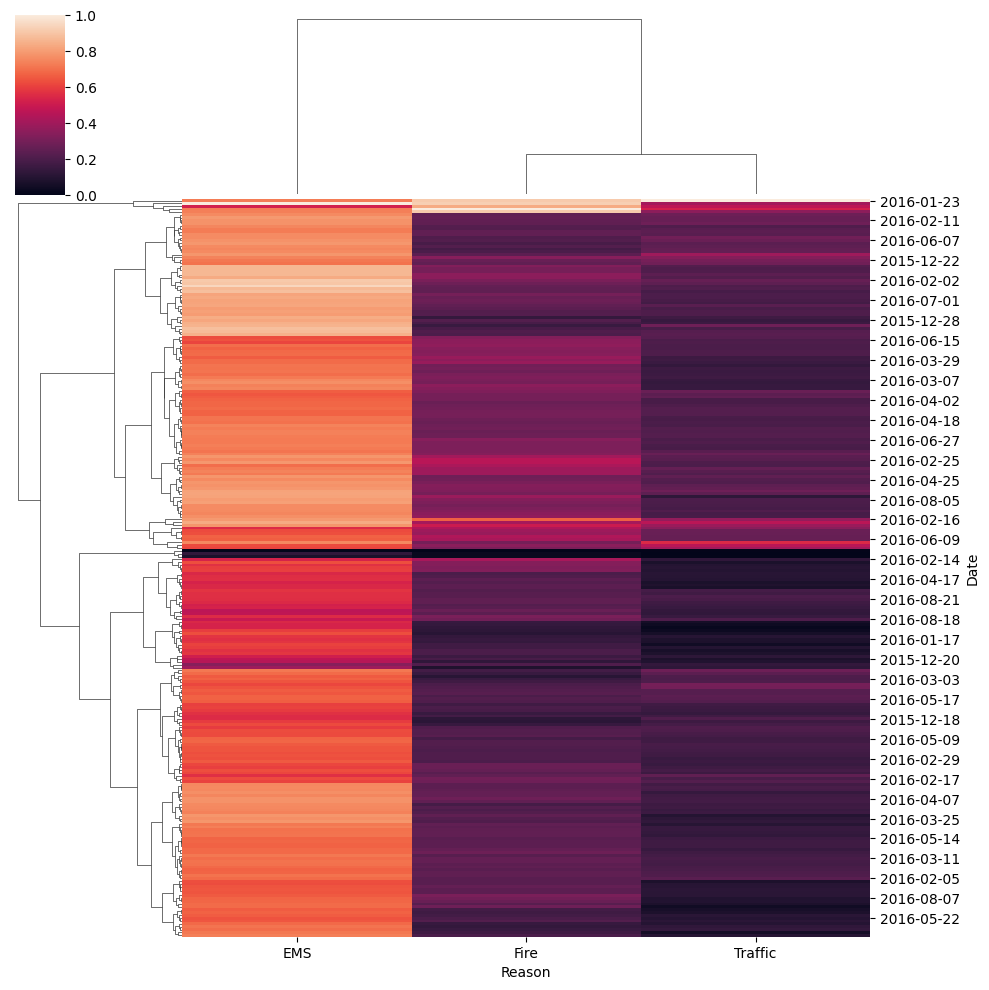

In [12]:
# pivot to matrix form (rows = Date, columns = Reason, values = counts)
byDateReason = (
    df.groupby(["Date", "Reason"])
      .size()
      .unstack(fill_value=0)
)

# clustermap with standard scaling on columns
sns.clustermap(byDateReason, method="ward", metric="euclidean", standard_scale=1)

> Repeating same same plots and operations, for a DataFrame that shows the Month as the column

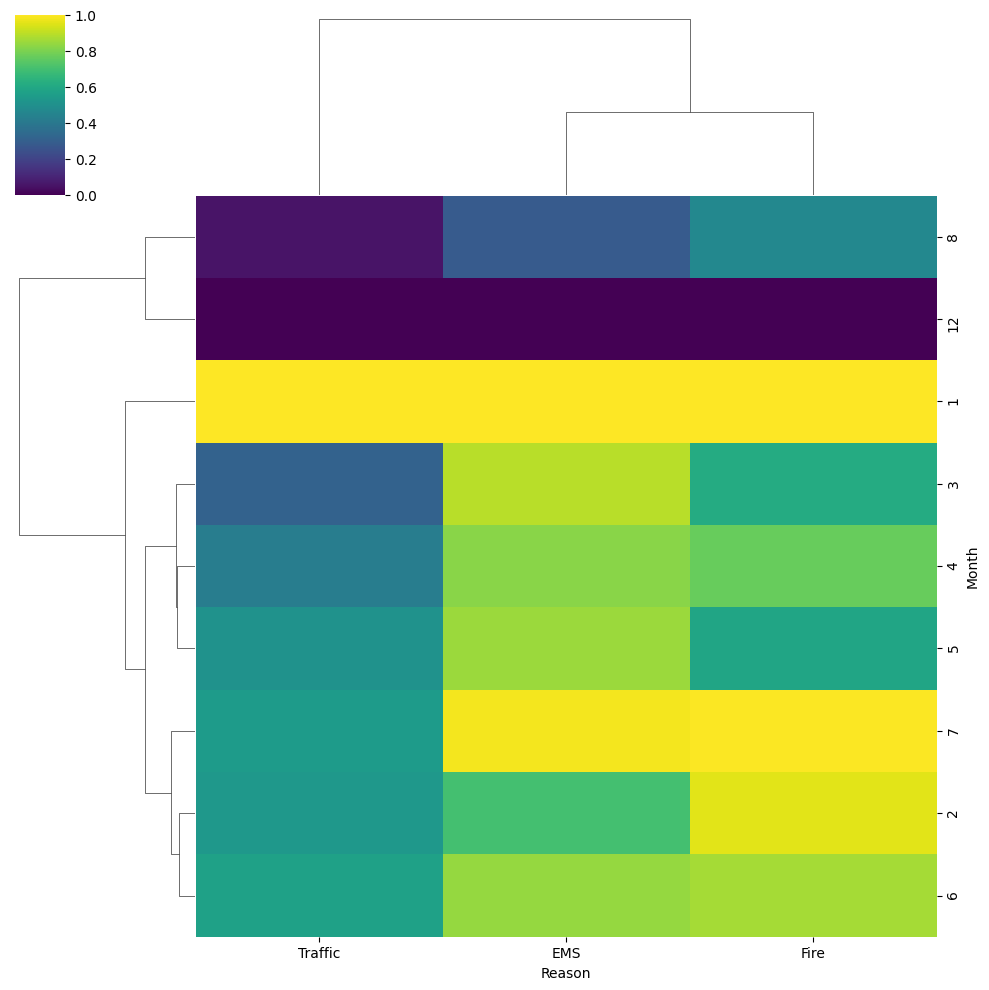

In [13]:
# pivot to matrix form (rows = Month, columns = Reason)
byMonthReason = (
    df.groupby(["Month", "Reason"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
)

# clustermap
sns.clustermap(
    byMonthReason,
    method="ward",
    metric="euclidean",
    standard_scale=1,
    cmap="viridis"
)

- **`heatmap()`** → shows data in the order you give it. Use **heatmap** when order matters (e.g. Month 1–12)

- **`clustermap()`** → reorders rows and columns based on similarity using hierarchical clustering, and adds dendrograms. Use **clustermap** when  discover grouping or similarity patterns is needed

If chronological order is important (like months), plain heatmap is usually more appropriate